In [1]:
# imports

import os
import json
from dotenv import load_dotenv
from openai import OpenAI
import gradio as gr
import sqlite3

# Initialization

load_dotenv(override=True)

openai_api_key = os.getenv('OPENAI_API_KEY')
if openai_api_key:
    print(f"OpenAI API Key exists and begins {openai_api_key[:8]}")
else:
    print("OpenAI API Key not set")
    
MODEL = "gpt-4.1-mini"
openai = OpenAI()

DB = "car_prices.db"

system_message = """
You are a helpful assistant for an Car Dealearship called SealerAI.
Give short, courteous answers, no more than 1 sentence.
Always be accurate. If you don't know the answer, say so.
"""


OpenAI API Key exists and begins sk-proj-


In [2]:
# create a database

def create_database():
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('CREATE TABLE IF NOT EXISTS car_prices (car TEXT PRIMARY KEY, price INTEGER)')
        conn.commit()

In [7]:
def get_car_price(car):
    print(f"DATABASE TOOL CALLED: Getting price for {car}", flush=True)
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('SELECT price FROM car_prices WHERE car = ?', (car.lower(),))
        result = cursor.fetchone()
        return f"Car price to {car} is ${result[0]}" if result else "No price data available for this car"

In [9]:
def set_car_price(car, price):
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('INSERT INTO car_prices (car, price) VALUES (?, ?) ON CONFLICT(car) DO UPDATE SET price = ?', (car.lower(), price, price))
        conn.commit()

In [10]:
# Test the database

create_database()
set_car_price("Malibu", 30000)
set_car_price("Cobalt", 10000)
set_car_price("Onix", 15000)
set_car_price("Tracker", 20000)

In [11]:
get_car_price("Cobalt")

DATABASE TOOL CALLED: Getting price for Cobalt


'Car price to Cobalt is $10000'

In [12]:
price_function = {
    "name": "get_car_price",
    "description": "Get the price of a car.",
    "parameters": {
        "type": "object",
        "properties": {
            "choosen_car": {
                "type": "string",
                "description": "The car that the customer wants to buy",
            },
        },
        "required": ["choosen_car"],
        "additionalProperties": False
    }
}
tools = [{"type": "function", "function": price_function}]
tools

[{'type': 'function',
  'function': {'name': 'get_car_price',
   'description': 'Get the price of a car.',
   'parameters': {'type': 'object',
    'properties': {'choosen_car': {'type': 'string',
      'description': 'The car that the customer wants to buy'}},
    'required': ['choosen_car'],
    'additionalProperties': False}}}]

In [14]:
def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses = handle_tool_calls(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    
    return response.choices[0].message.content

In [13]:
def handle_tool_calls(message):
    responses = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_car_price":
            arguments = json.loads(tool_call.function.arguments)
            car = arguments.get('choosen_car')
            price_details = get_car_price(car)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses

In [15]:
gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


DATABASE TOOL CALLED: Getting price for cobalt


In [16]:
# Some imports for handling images

import base64
from io import BytesIO
from PIL import Image

In [ ]:
def artist(car):
    image_response = openai.images.generate(
            model="gpt-image-1-mini",
            prompt=f"An image car {car}, in a vibrant pop-art style",
            size="1024x1024",
            n=1,
        )
    image_base64 = image_response.data[0].b64_json
    image_data = base64.b64decode(image_base64)
    return Image.open(BytesIO(image_data))

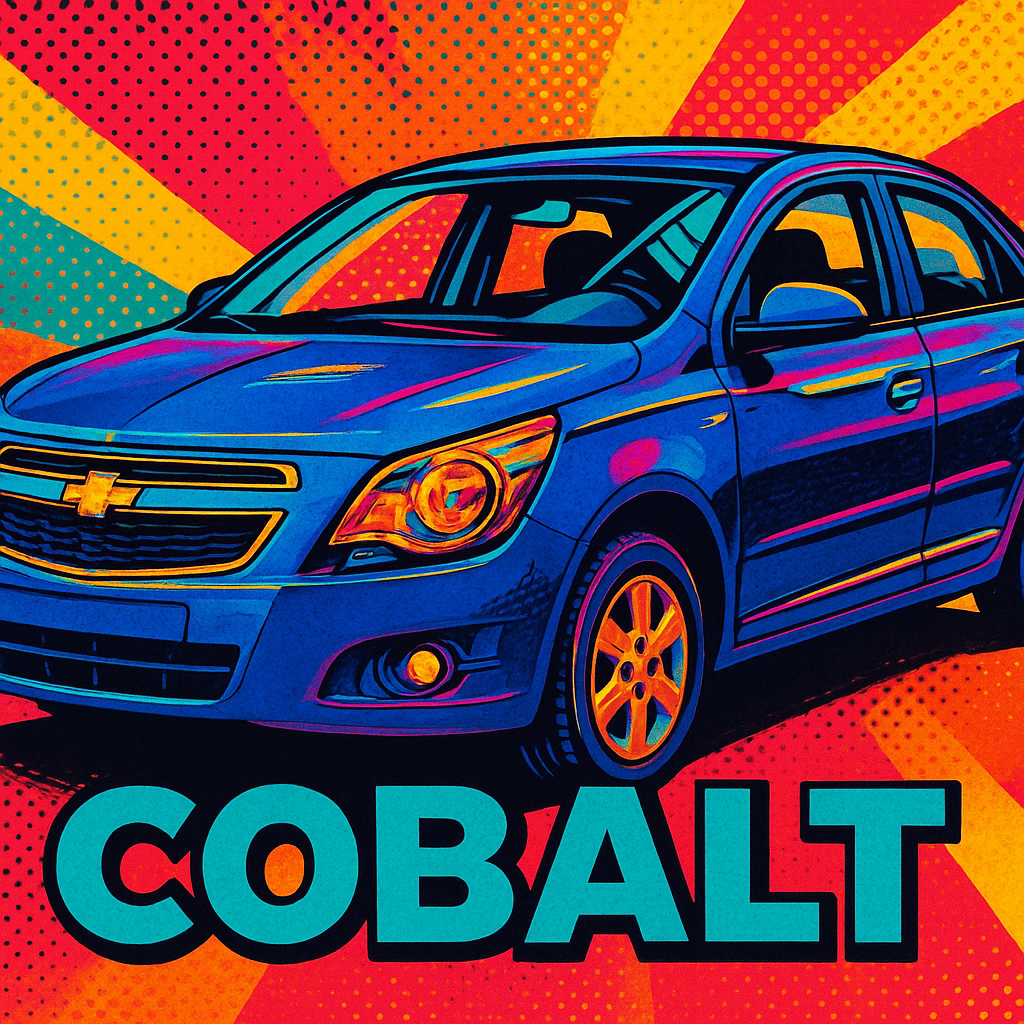

In [21]:
image = artist("Cobalt")
display(image)

In [34]:
def talker(message):
    response = openai.audio.speech.create(
      model="gpt-4o-mini-tts",
      voice="onyx",    # Also, try replacing onyx with alloy or coral
      input=message
    )
    return response.content

In [33]:
def chat(history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history
    response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    cars = []
    image = None

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses, cars = handle_tool_calls_and_return_cars(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    reply = response.choices[0].message.content
    history += [{"role":"assistant", "content":reply}]

    voice = talker(reply)

    if cars:
        image = artist(cars[0])
    
    return history, voice, image

In [32]:
def handle_tool_calls_and_return_cars(message):
    responses = []
    cars = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_car_price":
            arguments = json.loads(tool_call.function.arguments)
            car = arguments.get('choosen_car')
            cars.append(car)
            price_details = get_car_price(car)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses, cars

In [35]:
# Callbacks (along with the chat() function above)

def put_message_in_chatbot(message, history):
        return "", history + [{"role":"user", "content":message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500, type="messages")
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

# Hooking up events to callbacks

    message.submit(put_message_in_chatbot, inputs=[message, chatbot], outputs=[message, chatbot]).then(
        chat, inputs=chatbot, outputs=[chatbot, audio_output, image_output]
    )

ui.launch(inbrowser=True, auth=("jakha", "admin"))

* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.


DATABASE TOOL CALLED: Getting price for cobalt
